In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df[['Age','EstimatedSalary','Purchased']]

In [5]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [6]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [7]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled.shape

(400, 2)

In [10]:
#from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [11]:
#X_train.shape

In [12]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [13]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()

#Stochastic GD ---
history = model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2)
#print(time.time() - start)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8313 - loss: 0.4558 - val_accuracy: 0.6500 - val_loss: 0.6240
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8531 - loss: 0.3347 - val_accuracy: 0.6375 - val_loss: 0.5810
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8469 - loss: 0.3167 - val_accuracy: 0.6750 - val_loss: 0.5415
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8500 - loss: 0.3158 - val_accuracy: 0.6750 - val_loss: 0.5149
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8500 - loss: 0.3126 - val_accuracy: 0.6875 - val_loss: 0.4950
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.3100 - val_accuracy: 0.7000 - val_loss: 0.4776
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8469 - loss: 0.3058 - val_accuracy: 0.7000 - val_loss: 0.4650
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8531 - loss: 0.3035 - val_accu

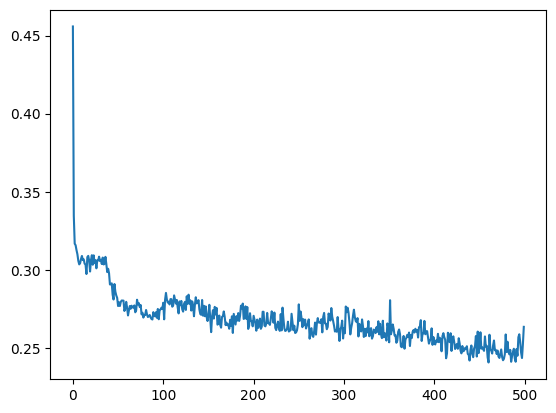

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [18]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])


# Batch GD --- take all data at once and only update weights = no.of epochs- in this case only 50 updates

history = model.fit(X_scaled,y,epochs=50,batch_size=len(X_scaled),validation_split=0.2)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9187 - loss: 0.2459 - val_accuracy: 0.8875 - val_loss: 0.2566
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9219 - loss: 0.2388 - val_accuracy: 0.8875 - val_loss: 0.2612
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9219 - loss: 0.2348 - val_accuracy: 0.8875 - val_loss: 0.2639
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9219 - loss: 0.2319 - val_accuracy: 0.8875 - val_loss: 0.2659
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9219 - loss: 0.2297 - val_accuracy: 0.8875 - val_loss: 0.2667
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9219 - loss: 0.2279 - val_accuracy: 0.8875 - val_loss: 0.2675
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9219 - loss: 0.2262 - val_accuracy: 0.8875 - val_loss: 0.2683
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9219 - loss: 0.2248 - val_accuracy: 0.8875 - val_loss: 0.2687
E

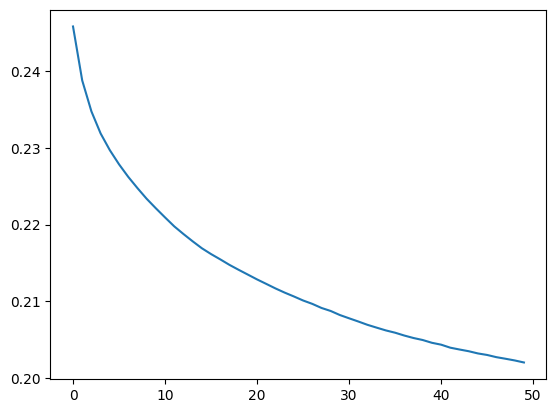

In [19]:
plt.plot(history.history['loss'])

In [20]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])


# Mini Batch GD --- Updates per epoch=⌈N/B⌉---Number of samples in dataset (N) Batch size (B)
history = model.fit(X_scaled,y,epochs=50,batch_size=32,validation_split=0.2)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9125 - loss: 0.2079 - val_accuracy: 0.8625 - val_loss: 0.2863
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2049 - val_accuracy: 0.8625 - val_loss: 0.2931
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9156 - loss: 0.2057 - val_accuracy: 0.8625 - val_loss: 0.2906
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9125 - loss: 0.2038 - val_accuracy: 0.8625 - val_loss: 0.2915
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9094 - loss: 0.2032 - val_accuracy: 0.8625 - val_loss: 0.2858
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9062 - loss: 0.2038 - val_accuracy: 0.8625 - val_loss: 0.2841
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2040 - val_accuracy: 0.8625 - val_loss: 0.2873
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9094 - loss: 0.2035 - val_accuracy: 0.8625 - val_lo

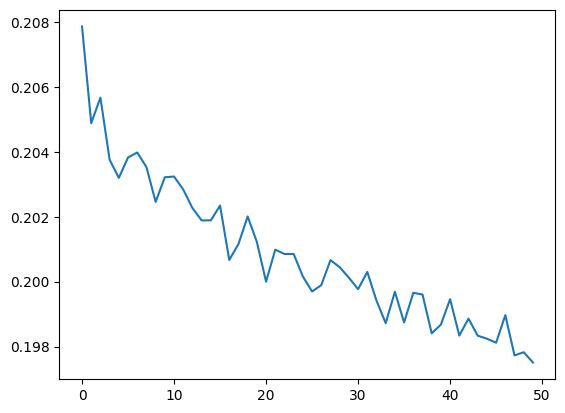

In [21]:
plt.plot(history.history['loss'])